In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
#bajar datos
today = pd.Timestamp.today()
start= today - pd.Timedelta(days=365)
start_date= start.strftime('%Y-%m-%d')
start_date

'2025-02-04'

In [3]:
symbol = 'SPY' #ticker
df_stock = yf.download(symbol, start=start_date, end=today.strftime('%Y-%m-%d'))[['Close']].copy()
df_stock


[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,SPY
Date,
2025-02-04,594.795227
2025-02-05,597.206848
2025-02-06,599.282532
2025-02-07,593.796936
2025-02-10,597.829529
...,...
2026-01-28,695.419983
2026-01-29,694.039978


In [4]:
#calcular los retornos logaritmicos diarios
#lo utilizamos para facilitar la simulacion y estadistica
#para generar simetría en la distribución normal
df_stock["returns"] = np.log(df_stock['Close'] / df_stock['Close'].shift(1))
df_stock

Price,Close,returns
Ticker,SPY,
Date,,
2025-02-04,594.795227,NaN
2025-02-05,597.206848,0.004046
2025-02-06,599.282532,0.003470
2025-02-07,593.796936,-0.009196
2025-02-10,597.829529,0.006768
...,...,...
2026-01-28,695.419983,-0.000101
2026-01-29,694.039978,-0.001986


In [5]:
#media y desviacion estandar de los retornos
mean_returns = df_stock['returns'].mean()
std_returns = df_stock['returns'].std()
mean_returns, std_returns

(np.float64(0.0005911722338864071), np.float64(0.012064286729144915))

In [6]:
#simulacion de monte carlo
def montecarlo_simulation(df_prices, n_simulations=10000, n_days=30, mu=0, sigma=0):
    #inicializar la matriz de procesos simulados (10000 * 30), con ceros
    simulated_prices = np.zeros((n_simulations, n_days))
    #El primer precio es el ultimo precio conocido
    initial_price = df_prices.iloc[-1]
    #asiganr el precio inicial a todas la simulaciones 
    simulated_prices[:,0] = initial_price

    #simular los precios para cada día y cada simulación
    for i in range(1, n_days):
        simulated_prices[:,i] = simulated_prices[:,i-1] * (1 + np.random.normal(mu, sigma, n_simulations)) 
    return simulated_prices

In [7]:
#ejecutar simulacion de 10000 caminos de 30 dias
simulated_prices = montecarlo_simulation(df_stock['Close'], n_simulations=10000, n_days=30, mu=mean_returns, sigma=std_returns)
simulated_prices

array([[689.5300293 , 703.58472307, 700.48005726, ..., 766.76099514,
        762.1180223 , 752.54369818],
       [689.5300293 , 684.59330658, 677.07450179, ..., 711.11178761,
        711.5849848 , 713.20396253],
       [689.5300293 , 691.45871891, 694.38072473, ..., 714.1544047 ,
        719.42415879, 700.01254779],
       ...,
       [689.5300293 , 700.38669278, 694.68239103, ..., 757.51613606,
        765.11039298, 774.49405953],
       [689.5300293 , 676.38997541, 680.2039264 , ..., 748.54445065,
        730.92884133, 732.25612288],
       [689.5300293 , 664.36609353, 666.38651723, ..., 729.02652534,
        728.34518446, 714.4147156 ]], shape=(10000, 30))

In [8]:
#percentiles y rangos de confianza
percentil_2_5 = np.percentile(simulated_prices[:,-1], 2.5)
percentil_97_5 = np.percentile(simulated_prices[:,-1], 97.5)

percentil_2_5, percentil_97_5

(np.float64(616.9965272551391), np.float64(795.2339388946727))

In [9]:
print(f"95% de confianza que el precio cierre en 30 días estará entre {percentil_2_5:.2f} y {percentil_97_5:.2f}")

95% de confianza que el precio cierre en 30 días estará entre 617.00 y 795.23


In [10]:
#valor eseperado la media de los precios simulados al final del periodo
expected_value = np.mean(simulated_prices[:,-1])
print(f"El valor esperado del precio de cierre en 30 días es {expected_value:.2f}")

El valor esperado del precio de cierre en 30 días es 701.67


In [11]:
#Calculo del VaR
confidence_interval = 0.95
simulated_prices_flat = simulated_prices[:,-1:].flatten()
simulated_prices

array([[689.5300293 , 703.58472307, 700.48005726, ..., 766.76099514,
        762.1180223 , 752.54369818],
       [689.5300293 , 684.59330658, 677.07450179, ..., 711.11178761,
        711.5849848 , 713.20396253],
       [689.5300293 , 691.45871891, 694.38072473, ..., 714.1544047 ,
        719.42415879, 700.01254779],
       ...,
       [689.5300293 , 700.38669278, 694.68239103, ..., 757.51613606,
        765.11039298, 774.49405953],
       [689.5300293 , 676.38997541, 680.2039264 , ..., 748.54445065,
        730.92884133, 732.25612288],
       [689.5300293 , 664.36609353, 666.38651723, ..., 729.02652534,
        728.34518446, 714.4147156 ]], shape=(10000, 30))

In [12]:
VaR=-np.percentile(simulated_prices_flat, 100*(1-confidence_interval))
print(f"El VaR al {confidence_interval*100:.0f} es {VaR:.2f}")

El VaR al 95 es -629.42


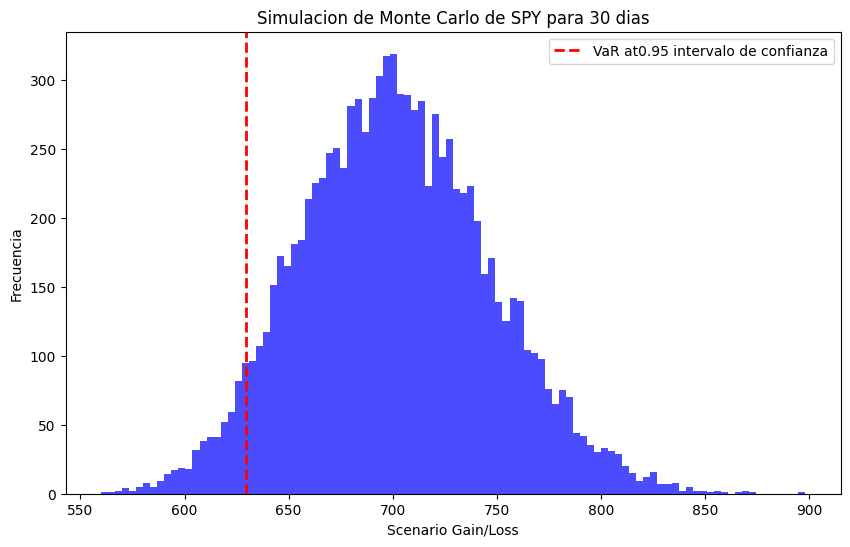

In [13]:
#mostrar grafico
plt.figure(figsize=(10,6))
plt.hist(simulated_prices_flat, bins=100, color='blue', alpha=0.7)
plt.title(f'Simulacion de Monte Carlo de {symbol} para 30 dias')
plt.xlabel('Scenario Gain/Loss')
plt.ylabel('Frecuencia')
plt.axvline(x=-VaR, color='r', linestyle='dashed', linewidth=2, label=f'VaR at{confidence_interval} intervalo de confianza')
plt.legend()
plt.show()

In [14]:
#interpretacion
#con un 95% de confianza, el valor nos indica que en en los proximos 30 días no perderemos más de 628.55 en precios de cierre